## Análise Exploratória dos Dados

Este notebook realiza a **análise exploratória** da base de ativos da B3 criada nas etapas anteriores do projeto.

O objetivo é entender o comportamento histórico dos ativos antes da modelagem, avaliando:

- distribuição da variável-alvo;
- frequência de superação do benchmark;
- retorno futuro médio;
- volatilidade;
- liquidez;
- drawdown;
- relação risco × retorno;
- correlação entre variáveis;
- classificação heurística de perfil de risco dos ativos.

> **Contexto de negócio:** uma fintech/corretora digital quer priorizar ativos com melhor relação entre retorno, risco e liquidez, respeitando a adequação ao perfil do investidor.

## 1. Preparação do ambiente

Nesta etapa importamos as bibliotecas, configuramos a exibição dos dados e criamos os diretórios onde serão salvos gráficos e tabelas do relatório.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# Pastas do projeto
DATA_DIRS = [
    Path("../data/processed"),
    Path("data/processed"),
]

IMAGES_DIRS = [
    Path("../images"),
    Path("images"),
]

TABLES_DIRS = [
    Path("../reports/tables"),
    Path("reports/tables"),
]


def get_existing_file(filename: str, directories: list[Path]) -> Path:
    """Localiza um arquivo procurando em múltiplos caminhos possíveis."""
    for directory in directories:
        path = directory / filename
        if path.exists():
            return path

    searched = "\n".join(str(directory / filename) for directory in directories)
    raise FileNotFoundError(f"Arquivo não encontrado. Caminhos testados:\n{searched}")


def get_or_create_dir(directories: list[Path]) -> Path:
    """Usa o primeiro diretório relativo que fizer sentido no ambiente atual."""
    directory = directories[0]
    directory.mkdir(parents=True, exist_ok=True)
    return directory


IMAGES_DIR = get_or_create_dir(IMAGES_DIRS)
TABLES_DIR = get_or_create_dir(TABLES_DIRS)

print("Pasta de imagens:", IMAGES_DIR)
print("Pasta de tabelas:", TABLES_DIR)

Pasta de imagens: ..\images
Pasta de tabelas: ..\reports\tables


## 2. Carregamento da base

A base `b3_features.csv` contém os dados tratados e as variáveis criadas na etapa de engenharia de atributos.

Cada linha representa:

> um ativo em uma data específica, com seus indicadores de retorno, risco, liquidez e o resultado futuro de superação do benchmark em 60 pregões.

In [2]:
data_path = get_existing_file("b3_features.csv", DATA_DIRS)

df = pd.read_csv(data_path)
df["data_pregao"] = pd.to_datetime(df["data_pregao"])

print("Base carregada com sucesso.")
print("Caminho:", data_path)
print("Shape:", df.shape)
print("Período:", df["data_pregao"].min(), "até", df["data_pregao"].max())
print("Quantidade de ativos:", df["ticker"].nunique())

df.head()

Base carregada com sucesso.
Caminho: ..\data\processed\b3_features.csv
Shape: (57200, 35)
Período: 2019-01-11 00:00:00 até 2025-10-02 00:00:00
Quantidade de ativos: 35


,data_pregao,ticker,cod_bdi,tipo_mercado,nome_empresa,especificacao,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,numero_negocios,quantidade_negociada,volume_negociado,retorno_1d,retorno_7d,retorno_21d,retorno_63d,retorno_126d,retorno_252d,volatilidade_21d,volatilidade_63d,volatilidade_126d,volume_medio_21d,volume_medio_63d,negocios_medio_21d,amplitude_intradiaria,amplitude_media_21d,drawdown_252d,distancia_maxima_252d,sharpe_aprox_63d,retorno_futuro_60d,retorno_futuro_60d_benchmark,retorno_1d_benchmark,target_supera_benchmark_60d
0,2019-01-11,ABEV3,2,10,AMBEV S/A,ON,17.0200,17.2900,16.8800,17.0700,17.2900,82408,73632000,125714492000,0.0261,0.0706,0.0732,-0.0325,-0.0603,-0.2029,0.3030,0.3170,0.2698,34525939366.6667,34787468426.9841,32188.0000,0.0237,0.0283,-0.2876,-0.2876,-0.1024,0.0150,0.0233,-0.0004,0
1,2019-01-14,ABEV3,2,10,AMBEV S/A,ON,17.2400,17.6600,17.1000,17.4900,17.5400,48520,31707300,55460853100,0.0145,0.0741,0.1038,-0.0062,-0.0304,-0.1932,0.2986,0.3175,0.2696,35594422319.0476,35212084461.9048,32616.1429,0.0319,0.0284,-0.2773,-0.2773,-0.0196,-0.0165,0.0019,0.0092,0
2,2019-01-15,ABEV3,2,10,AMBEV S/A,ON,17.5700,17.7900,17.3000,17.6600,17.7000,46403,35536600,62776312300,0.0091,0.0695,0.1097,-0.0167,-0.0269,-0.1813,0.2989,0.3155,0.2698,37204774180.9524,35444913892.0635,33789.8095,0.0277,0.0288,-0.2707,-0.2707,-0.0528,-0.0362,-0.0121,-0.0066,0
3,2019-01-16,ABEV3,2,10,AMBEV S/A,ON,17.7000,17.8400,17.5600,17.7000,17.8000,30619,19990600,35398484900,0.0056,0.0801,0.1160,0.0183,-0.0061,-0.1797,0.2983,0.3102,0.2690,37293064604.7619,35456668474.6032,33633.3810,0.0157,0.0286,-0.2666,-0.2666,0.0590,-0.0213,-0.0147,0.0060,0
4,2019-01-17,ABEV3,2,10,AMBEV S/A,ON,17.6800,17.9100,17.4800,17.7400,17.8500,42784,22422400,39777918400,0.0028,0.1053,0.0938,0.0378,-0.0214,-0.1759,0.2913,0.3084,0.2678,38139026838.0952,35778870525.3968,34570.7619,0.0241,0.0288,-0.2645,-0.2645,0.1226,-0.0179,-0.0105,0.0090,0


## 3. Validação inicial

Antes de analisar, verificamos:

- tamanho da base;
- tipos das colunas;
- presença de valores ausentes;
- quantidade de ativos;
- período analisado.

Essa validação ajuda a garantir que a análise exploratória está partindo de uma base coerente.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57200 entries, 0 to 57199
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   data_pregao                   57200 non-null  datetime64[us]
 1   ticker                        57200 non-null  str           
 2   cod_bdi                       57200 non-null  int64         
 3   tipo_mercado                  57200 non-null  int64         
 4   nome_empresa                  57200 non-null  str           
 5   especificacao                 57200 non-null  str           
 6   preco_abertura                57200 non-null  float64       
 7   preco_maximo                  57200 non-null  float64       
 8   preco_minimo                  57200 non-null  float64       
 9   preco_medio                   57200 non-null  float64       
 10  preco_fechamento              57200 non-null  float64       
 11  numero_negocios               57200 non

In [4]:
resumo_base = pd.DataFrame({
    "metrica": [
        "linhas",
        "colunas",
        "ativos_unicos",
        "data_inicial",
        "data_final",
        "percentual_nulos_total",
    ],
    "valor": [
        df.shape[0],
        df.shape[1],
        df["ticker"].nunique(),
        df["data_pregao"].min(),
        df["data_pregao"].max(),
        df.isna().mean().mean(),
    ],
})

resumo_base

,metrica,valor
0,linhas,57200
1,colunas,35
2,ativos_unicos,35
3,data_inicial,2019-01-11 00:00:00
4,data_final,2025-10-02 00:00:00
5,percentual_nulos_total,0.0001


In [5]:
nulos_por_coluna = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("percentual_nulos")
    .reset_index()
    .rename(columns={"index": "coluna"})
)

nulos_por_coluna.head(15)

,coluna,percentual_nulos
0,retorno_futuro_60d,0.0043
1,ticker,0.0000
2,data_pregao,0.0000
3,cod_bdi,0.0000
4,tipo_mercado,0.0000
5,especificacao,0.0000
6,nome_empresa,0.0000
7,preco_maximo,0.0000
8,preco_minimo,0.0000
9,preco_medio,0.0000


## 4. Distribuição da variável-alvo

A variável-alvo do projeto é:

`target_supera_benchmark_60d`

- `0`: o ativo **não superou** o benchmark nos próximos 60 pregões;
- `1`: o ativo **superou** o benchmark nos próximos 60 pregões.

Essa análise mostra se o problema de classificação está muito desbalanceado ou não.

In [6]:
target_col = "target_supera_benchmark_60d"

target_dist = (
    df[target_col]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proporcao")
    .reset_index()
    .rename(columns={"index": "classe"})
)

target_dist

,target_supera_benchmark_60d,proporcao
0,0,0.5458
1,1,0.4542


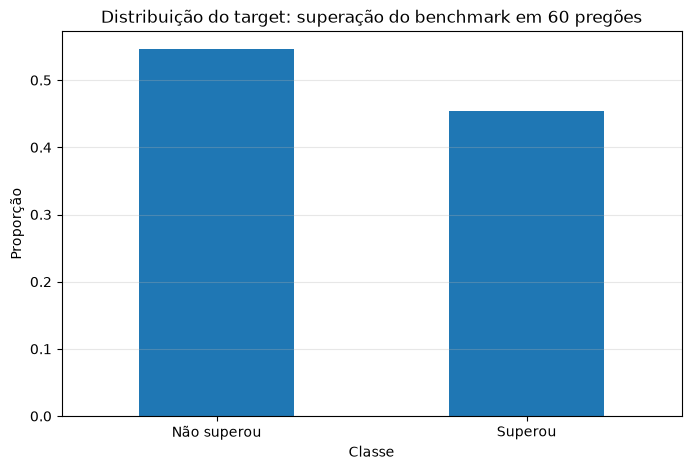

target_supera_benchmark_60d
0   0.5458
1   0.4542
Name: proportion, dtype: float64

In [7]:
target_dist = df["target_supera_benchmark_60d"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

target_dist.plot(kind="bar", ax=ax)

ax.set_title("Distribuição do target: superação do benchmark em 60 pregões")
ax.set_xlabel("Classe")
ax.set_ylabel("Proporção")
ax.set_xticklabels(["Não superou", "Superou"], rotation=0)
ax.grid(axis="y", alpha=0.3)

fig.savefig("../images/distribuicao_target.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

target_dist

### Interpretação

A variável-alvo ficou relativamente equilibrada, o que é positivo para a modelagem supervisionada.  
Caso uma classe fosse muito dominante, o modelo poderia aprender a favorecer sempre a classe majoritária.

## 5. Frequência de superação do benchmark por ativo

Aqui calculamos a proporção histórica de vezes em que cada ativo superou o benchmark em uma janela futura de 60 pregões.

Essa métrica não é uma previsão direta, mas ajuda a entender quais ativos tiveram maior consistência relativa no período analisado.

In [8]:
ranking_superacao = (
    df.groupby("ticker")[target_col]
    .mean()
    .sort_values(ascending=False)
)

ranking_superacao.head(15)

ticker
SBSP3    0.6462
WEGE3    0.5931
TIMS3    0.5860
BPAC11   0.5835
VIVA3    0.5174
JBSS3    0.5160
PRIO3    0.5072
EQTL3    0.5066
BRFS3    0.4952
PETR4    0.4821
VALE3    0.4755
RADL3    0.4732
PETR3    0.4726
ITUB4    0.4660
TAEE11   0.4582
Name: target_supera_benchmark_60d, dtype: float64

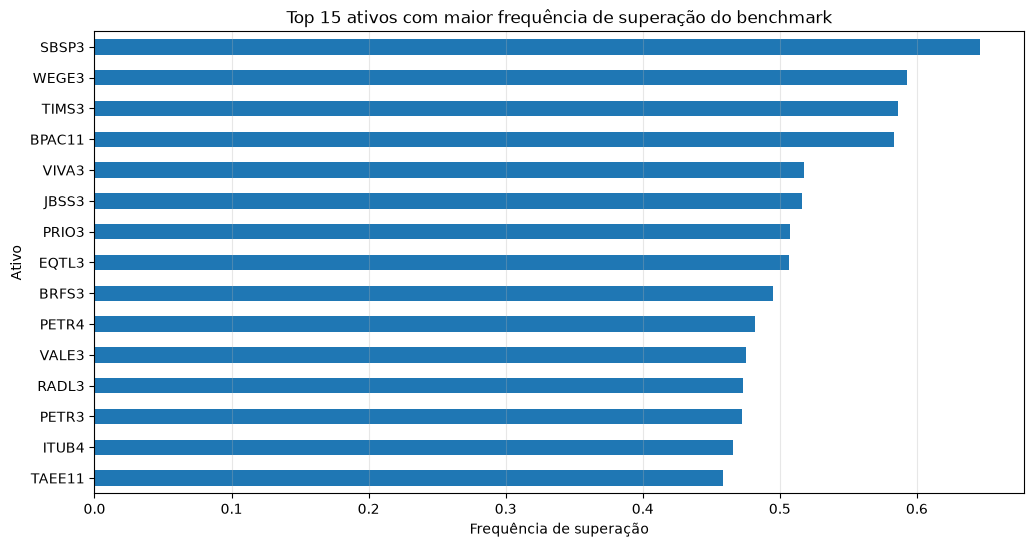

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ranking_superacao.head(15).sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 15 ativos com maior frequência de superação do benchmark")
ax.set_xlabel("Frequência de superação")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_15_superacao_benchmark.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Ativos com maior frequência de superação demonstraram melhor desempenho relativo histórico frente ao benchmark.  
Essa métrica deve ser analisada junto de risco, liquidez e drawdown, pois alta frequência de superação não garante adequação a todos os perfis de investidor.

## 6. Retorno futuro médio por ativo

Nesta etapa avaliamos o retorno médio futuro em 60 pregões.

> Atenção: retorno isolado não é suficiente para recomendação.  
> Um ativo pode apresentar retorno médio alto por causa de movimentos de recuperação após quedas severas.

In [10]:
retorno_medio_futuro = (
    df.groupby("ticker")["retorno_futuro_60d"]
    .mean()
    .sort_values(ascending=False)
)

retorno_medio_futuro.head(15)

ticker
HAPV3    0.4713
MGLU3    0.1526
PRIO3    0.0884
BPAC11   0.0731
JBSS3    0.0583
WEGE3    0.0581
SBSP3    0.0567
TIMS3    0.0437
CSNA3    0.0310
ELET3    0.0304
VIVA3    0.0285
RENT3    0.0281
GGBR4    0.0277
ELET6    0.0273
BRFS3    0.0265
Name: retorno_futuro_60d, dtype: float64

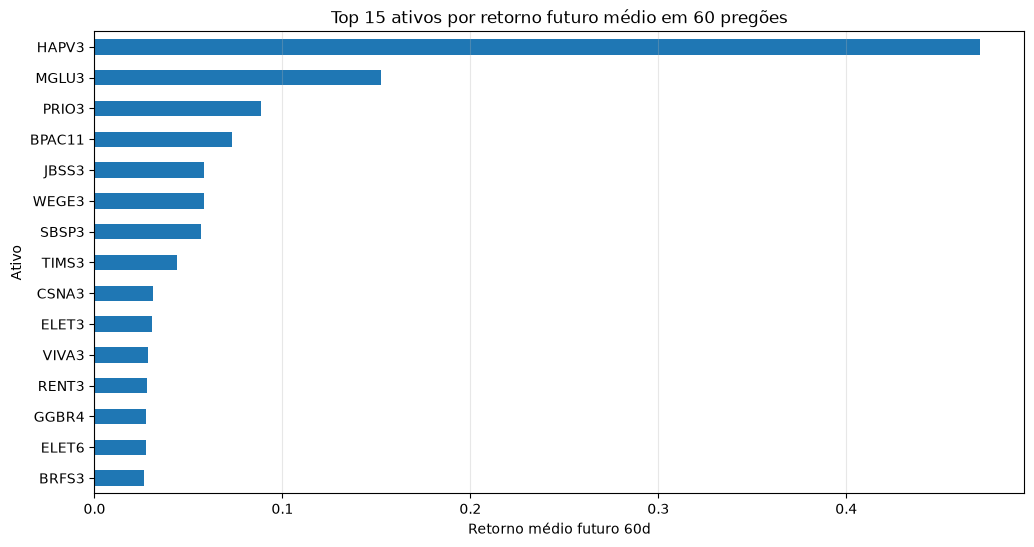

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

retorno_medio_futuro.head(15).sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 15 ativos por retorno futuro médio em 60 pregões")
ax.set_xlabel("Retorno médio futuro 60d")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_15_retorno_medio_60d.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

O retorno médio ajuda a identificar ativos com maior ganho histórico em janelas futuras, mas precisa ser combinado com métricas de risco.  
Em uma aplicação real de fintech, recomendar apenas com base em retorno seria uma abordagem incompleta.

## 7. Volatilidade média por ativo

A volatilidade mede a intensidade das oscilações dos preços.

- volatilidade baixa: ativo mais estável;
- volatilidade alta: ativo mais agressivo.

Para uma fintech, essa métrica é essencial para avaliar adequação ao perfil do investidor.

In [12]:
risco_medio = (
    df.groupby("ticker")["volatilidade_63d"]
    .mean()
    .sort_values(ascending=False)
)

risco_medio.head(15)

ticker
HAPV3    1.6226
MGLU3    1.3703
PRIO3    0.6010
CSNA3    0.5019
BRFS3    0.4689
BPAC11   0.4580
LREN3    0.4341
UGPA3    0.4284
B3SA3    0.4242
RENT3    0.4048
PETR3    0.3918
ELET3    0.3900
PETR4    0.3843
VIVA3    0.3829
JBSS3    0.3808
Name: volatilidade_63d, dtype: float64

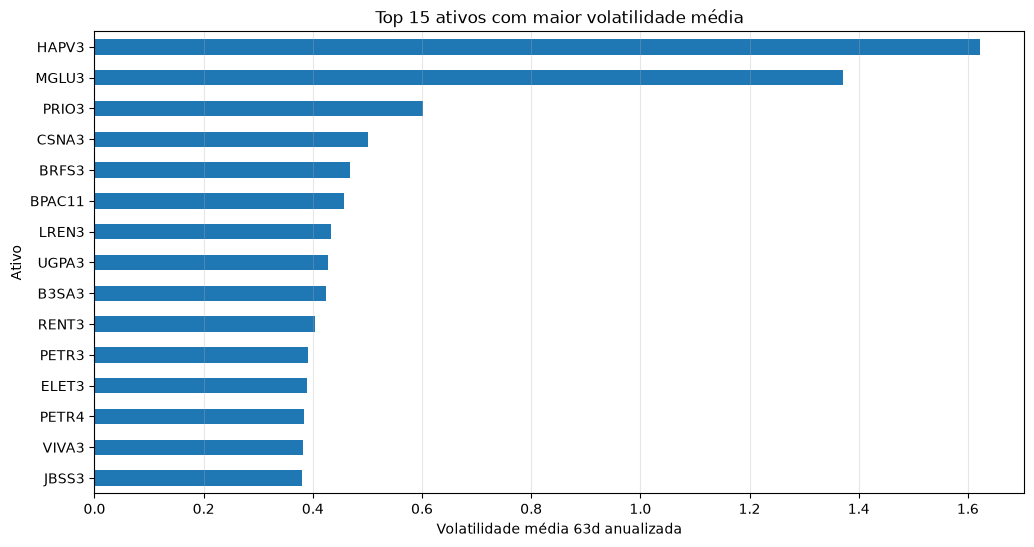

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

risco_medio.head(15).sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 15 ativos com maior volatilidade média")
ax.set_xlabel("Volatilidade média 63d anualizada")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_15_volatilidade.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Ativos mais voláteis podem ter maior potencial de retorno, mas também maior risco de perdas.  
Essa informação será usada depois para classificar ativos em perfis como moderado, arrojado ou especulativo.

## 8. Liquidez média por ativo

A liquidez representa a facilidade de comprar ou vender um ativo sem grande impacto no preço.

Para uma fintech/corretora, ativos mais líquidos tendem a ser mais adequados para recomendação em escala.

In [14]:
liquidez_media = (
    df.groupby("ticker")["volume_medio_21d"]
    .mean()
    .sort_values(ascending=False)
)

liquidez_media.head(15)

ticker
VALE3   179285282417.6270
PETR4   171994695966.6269
ITUB4    88585180310.1972
BBDC4    74211988078.5402
BBAS3    56484592266.9565
B3SA3    56112212920.7643
MGLU3    50547050723.4487
PETR3    47277827159.3775
ABEV3    39189824367.2292
RENT3    35568202063.7430
SUZB3    34122089590.0585
PRIO3    33029305589.1664
LREN3    30470811975.8808
JBSS3    30272767639.4135
ELET3    28585146035.2029
Name: volume_medio_21d, dtype: float64

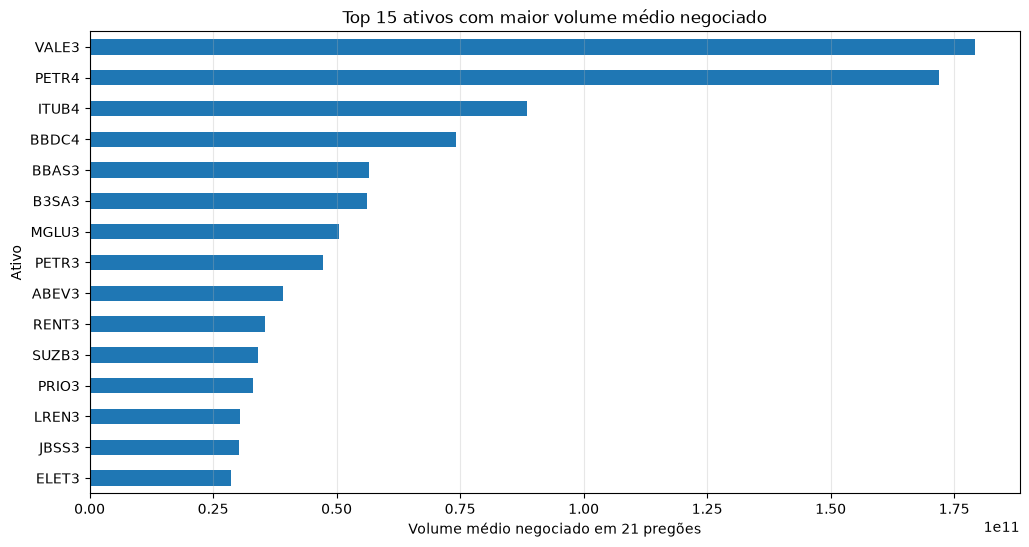

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

liquidez_media.head(15).sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 15 ativos com maior volume médio negociado")
ax.set_xlabel("Volume médio negociado em 21 pregões")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_15_liquidez.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Ativos líquidos tendem a ter melhor execução, menor risco de saída e maior aderência para recomendação em massa.  
Por isso, liquidez é uma variável importante em soluções voltadas a corretoras e fintechs.

## 9. Tabela consolidada de risco × retorno

Agora agregamos as principais métricas por ativo em uma única tabela:

- retorno médio futuro;
- volatilidade média;
- liquidez média;
- taxa de superação;
- drawdown médio;
- Sharpe aproximado.

Essa tabela será usada para visualização, ranking e classificação de perfil.

In [16]:
risco_retorno = (
    df.groupby("ticker")
    .agg(
        retorno_medio_60d=("retorno_futuro_60d", "mean"),
        volatilidade_media_63d=("volatilidade_63d", "mean"),
        liquidez_media_21d=("volume_medio_21d", "mean"),
        taxa_superacao=(target_col, "mean"),
        drawdown_medio_252d=("drawdown_252d", "mean"),
        sharpe_medio_63d=("sharpe_aprox_63d", "mean"),
    )
    .reset_index()
)

risco_retorno.head()

,ticker,retorno_medio_60d,volatilidade_media_63d,liquidez_media_21d,taxa_superacao,drawdown_medio_252d,sharpe_medio_63d
0,ABEV3,-0.0023,0.2738,39189824367.2292,0.3938,-0.1777,-0.0032
1,B3SA3,-0.0013,0.4242,56112212920.7643,0.4296,-0.2545,0.0416
2,BBAS3,-0.0103,0.3449,56484592266.9565,0.4200,-0.2293,0.0779
3,BBDC4,-0.0150,0.3377,74211988078.5402,0.3049,-0.2429,-0.0134
4,BPAC11,0.0731,0.4580,27893062628.4123,0.5835,-0.2170,0.3090


In [17]:
# Melhores ativos por frequência de superação
risco_retorno.sort_values("taxa_superacao", ascending=False).head(10)

,ticker,retorno_medio_60d,volatilidade_media_63d,liquidez_media_21d,taxa_superacao,drawdown_medio_252d,sharpe_medio_63d
26,SBSP3,0.0567,0.3406,21036171885.2142,0.6462,-0.1321,0.2308
34,WEGE3,0.0581,0.3606,27435445167.9452,0.5931,-0.2026,0.2222
29,TIMS3,0.0437,0.2497,11119091797.0551,0.5860,-0.0848,0.1834
4,BPAC11,0.0731,0.4580,27893062628.4123,0.5835,-0.2170,0.3090
32,VIVA3,0.0285,0.3829,5462363253.4973,0.5174,-0.2038,0.0981
15,JBSS3,0.0583,0.3808,30272767639.4135,0.5160,-0.1829,0.2056
21,PRIO3,0.0884,0.6010,33029305589.1664,0.5072,-0.3516,0.2338
11,EQTL3,0.0041,0.3195,20155762378.3527,0.5066,-0.1852,0.1453
5,BRFS3,0.0265,0.4689,19212285267.4460,0.4952,-0.2866,0.0819
20,PETR4,0.0213,0.3843,171994695966.6269,0.4821,-0.1625,0.1091


In [18]:
# Melhores ativos por retorno médio futuro
risco_retorno.sort_values("retorno_medio_60d", ascending=False).head(10)

,ticker,retorno_medio_60d,volatilidade_media_63d,liquidez_media_21d,taxa_superacao,drawdown_medio_252d,sharpe_medio_63d
13,HAPV3,0.4713,1.6226,24037436078.2453,0.4240,-0.3848,0.0390
18,MGLU3,0.1526,1.3703,50547050723.4487,0.4147,-0.5491,-0.0310
21,PRIO3,0.0884,0.6010,33029305589.1664,0.5072,-0.3516,0.2338
4,BPAC11,0.0731,0.4580,27893062628.4123,0.5835,-0.2170,0.3090
15,JBSS3,0.0583,0.3808,30272767639.4135,0.5160,-0.1829,0.2056
34,WEGE3,0.0581,0.3606,27435445167.9452,0.5931,-0.2026,0.2222
26,SBSP3,0.0567,0.3406,21036171885.2142,0.6462,-0.1321,0.2308
29,TIMS3,0.0437,0.2497,11119091797.0551,0.5860,-0.0848,0.1834
8,CSNA3,0.0310,0.5019,20167573790.4535,0.3896,-0.3262,0.0635
9,ELET3,0.0304,0.3900,28585146035.2029,0.4403,-0.1731,0.1051


In [19]:
risco_retorno.to_csv(TABLES_DIR / "risco_retorno_por_ativo.csv", index=False)

## 10. Mapa risco × retorno

O mapa de risco × retorno permite visualizar o equilíbrio entre:

- retorno médio futuro;
- volatilidade média;
- frequência de superação do benchmark.

No gráfico, o tamanho da bolha representa a taxa de superação do benchmark.

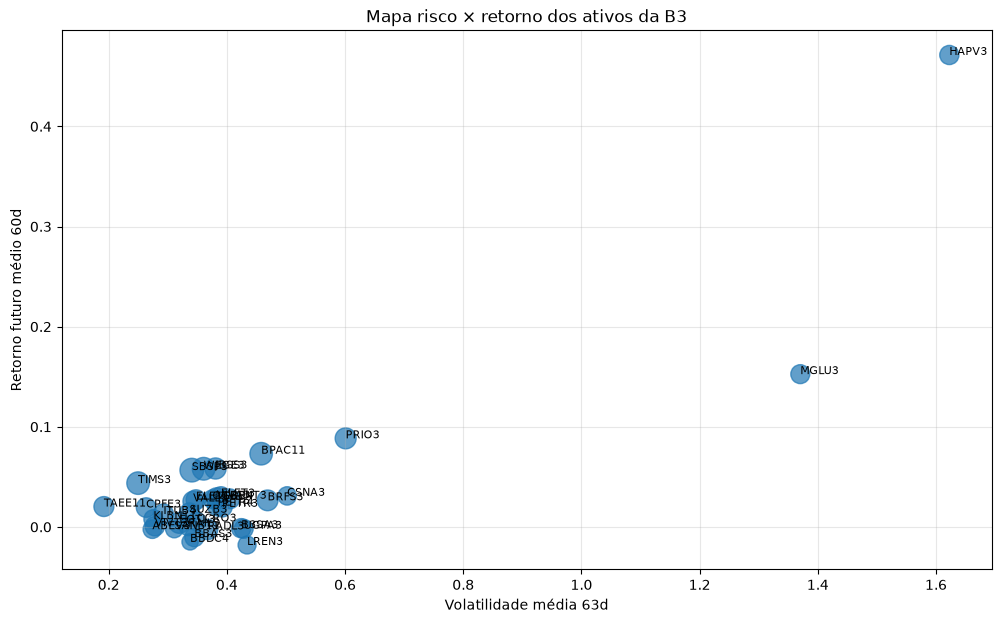

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    risco_retorno["volatilidade_media_63d"],
    risco_retorno["retorno_medio_60d"],
    s=risco_retorno["taxa_superacao"] * 450,
    alpha=0.7,
)

for _, row in risco_retorno.iterrows():
    ax.text(
        row["volatilidade_media_63d"],
        row["retorno_medio_60d"],
        row["ticker"],
        fontsize=8,
    )

ax.set_title("Mapa risco × retorno dos ativos da B3")
ax.set_xlabel("Volatilidade média 63d")
ax.set_ylabel("Retorno futuro médio 60d")
ax.grid(True, alpha=0.3)

fig.savefig(IMAGES_DIR / "mapa_risco_retorno.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Ativos no canto superior esquerdo são os mais interessantes do ponto de vista de risco-retorno, pois combinam maior retorno médio com menor volatilidade relativa.  
Ativos mais à direita exigem maior tolerância ao risco.

## 11. Mapa risco × retorno sem outliers visuais

Alguns ativos podem distorcer a escala do gráfico por apresentarem volatilidade e retorno muito superiores ao restante do grupo.

Abaixo removemos apenas **outliers visuais** para melhorar a leitura dos demais ativos.  
Eles não são removidos da base de modelagem.

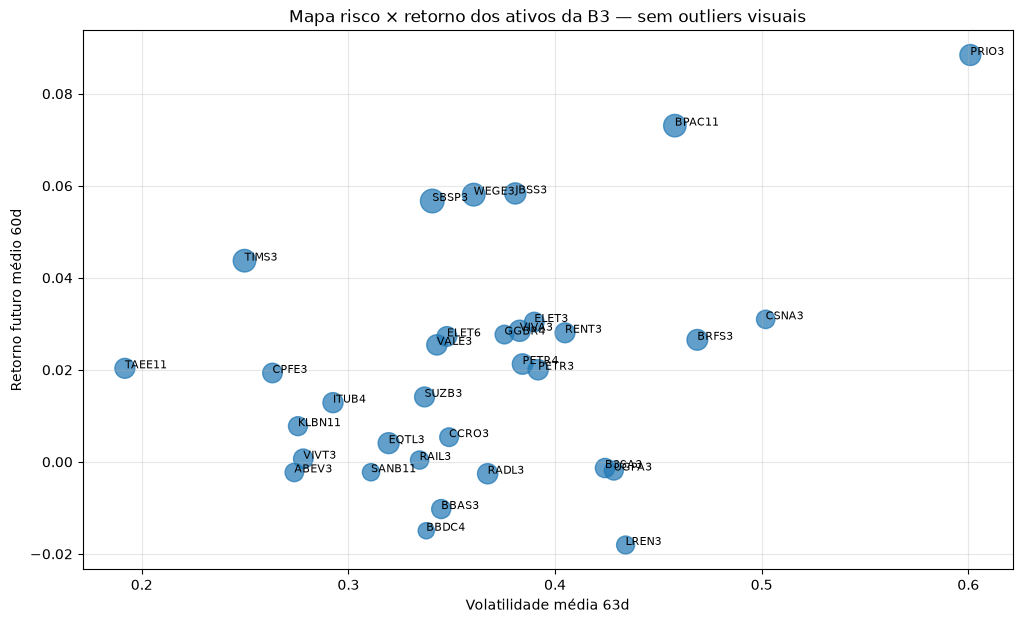

In [21]:
outliers_visuais = ["HAPV3", "MGLU3"]

risco_retorno_zoom = risco_retorno[
    ~risco_retorno["ticker"].isin(outliers_visuais)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    risco_retorno_zoom["volatilidade_media_63d"],
    risco_retorno_zoom["retorno_medio_60d"],
    s=risco_retorno_zoom["taxa_superacao"] * 450,
    alpha=0.7,
)

for _, row in risco_retorno_zoom.iterrows():
    ax.text(
        row["volatilidade_media_63d"],
        row["retorno_medio_60d"],
        row["ticker"],
        fontsize=8,
    )

ax.set_title("Mapa risco × retorno dos ativos da B3 — sem outliers visuais")
ax.set_xlabel("Volatilidade média 63d")
ax.set_ylabel("Retorno futuro médio 60d")
ax.grid(True, alpha=0.3)

fig.savefig(IMAGES_DIR / "mapa_risco_retorno_sem_outliers.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

## 12. Drawdown médio por ativo

O drawdown mede a queda de um ativo em relação à sua máxima recente.

Essa é uma métrica muito importante para investidor pessoa física, pois representa a “dor” de ver a carteira cair.

In [22]:
drawdown_medio = (
    df.groupby("ticker")["drawdown_252d"]
    .mean()
    .sort_values()
)

drawdown_medio.head(15)

ticker
MGLU3    -0.5491
HAPV3    -0.3848
PRIO3    -0.3516
CSNA3    -0.3262
UGPA3    -0.3078
BRFS3    -0.2866
LREN3    -0.2608
RADL3    -0.2550
B3SA3    -0.2545
BBDC4    -0.2429
BBAS3    -0.2293
GGBR4    -0.2173
BPAC11   -0.2170
VIVA3    -0.2038
WEGE3    -0.2026
Name: drawdown_252d, dtype: float64

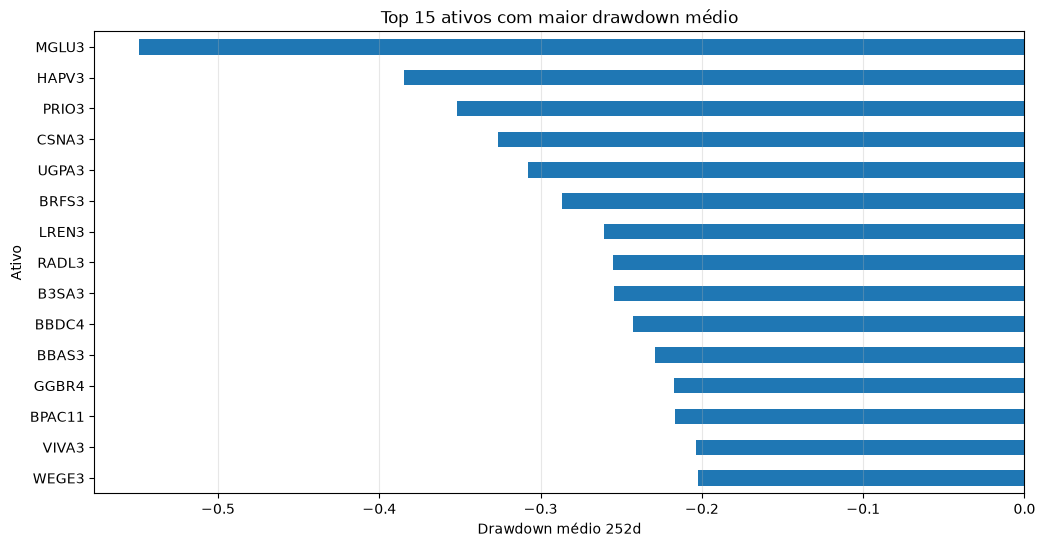

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

drawdown_medio.head(15).sort_values(ascending=False).plot(kind="barh", ax=ax)

ax.set_title("Top 15 ativos com maior drawdown médio")
ax.set_xlabel("Drawdown médio 252d")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_15_drawdown.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Quanto mais negativo o drawdown, maior foi a queda média em relação à máxima recente.  
Ativos com drawdown elevado podem ser inadequados para investidores conservadores.

## 13. Correlação entre variáveis

A matriz de correlação ajuda a identificar relações lineares entre as variáveis.

Ela também ajuda a entender redundância entre features, como diferentes janelas de volatilidade ou retorno.

In [24]:
feature_cols_corr = [
    "retorno_7d",
    "retorno_21d",
    "retorno_63d",
    "retorno_126d",
    "retorno_252d",
    "volatilidade_21d",
    "volatilidade_63d",
    "volatilidade_126d",
    "volume_medio_21d",
    "negocios_medio_21d",
    "amplitude_media_21d",
    "drawdown_252d",
    "sharpe_aprox_63d",
    "retorno_futuro_60d",
    target_col,
]

corr = df[feature_cols_corr].corr()

corr

,retorno_7d,retorno_21d,retorno_63d,retorno_126d,retorno_252d,volatilidade_21d,volatilidade_63d,volatilidade_126d,volume_medio_21d,negocios_medio_21d,amplitude_media_21d,drawdown_252d,sharpe_aprox_63d,retorno_futuro_60d,target_supera_benchmark_60d
retorno_7d,1.0000,0.6281,0.3660,0.2516,0.1914,0.4999,0.2989,0.2372,-0.0131,-0.0020,0.0306,0.0906,0.1171,-0.0039,-0.0012
retorno_21d,0.6281,1.0000,0.5966,0.4345,0.3274,0.8529,0.5056,0.4068,-0.0160,-0.0173,-0.0030,0.1485,0.2141,-0.0120,-0.0105
retorno_63d,0.3660,0.5966,1.0000,0.7688,0.5412,0.5108,0.8561,0.6972,-0.0145,-0.0468,-0.0315,0.2151,0.3747,-0.0419,-0.0323
retorno_126d,0.2516,0.4345,0.7688,1.0000,0.7110,0.3752,0.6720,0.8123,-0.0200,-0.0786,-0.0314,0.2899,0.2614,-0.0524,-0.0251
retorno_252d,0.1914,0.3274,0.5412,0.7110,1.0000,0.2416,0.4059,0.5044,-0.0036,-0.1205,-0.0364,0.5017,0.3189,-0.0823,-0.0325
volatilidade_21d,0.4999,0.8529,0.5108,0.3752,0.2416,1.0000,0.5873,0.4764,0.0098,0.0512,0.1961,-0.0792,-0.0144,0.0237,0.0006
volatilidade_63d,0.2989,0.5056,0.8561,0.6720,0.4059,0.5873,1.0000,0.8109,-0.0032,0.0369,0.1808,-0.0825,0.0038,0.0096,-0.0186
volatilidade_126d,0.2372,0.4068,0.6972,0.8123,0.5044,0.4764,0.8109,1.0000,-0.0077,0.0354,0.1784,-0.1029,0.0097,-0.0057,-0.0351
volume_medio_21d,-0.0131,-0.0160,-0.0145,-0.0200,-0.0036,0.0098,-0.0032,-0.0077,1.0000,0.7898,0.0017,-0.0263,-0.0016,-0.0274,-0.0209
negocios_medio_21d,-0.0020,-0.0173,-0.0468,-0.0786,-0.1205,0.0512,0.0369,0.0354,0.7898,1.0000,0.2475,-0.2534,-0.0898,0.0279,-0.0386


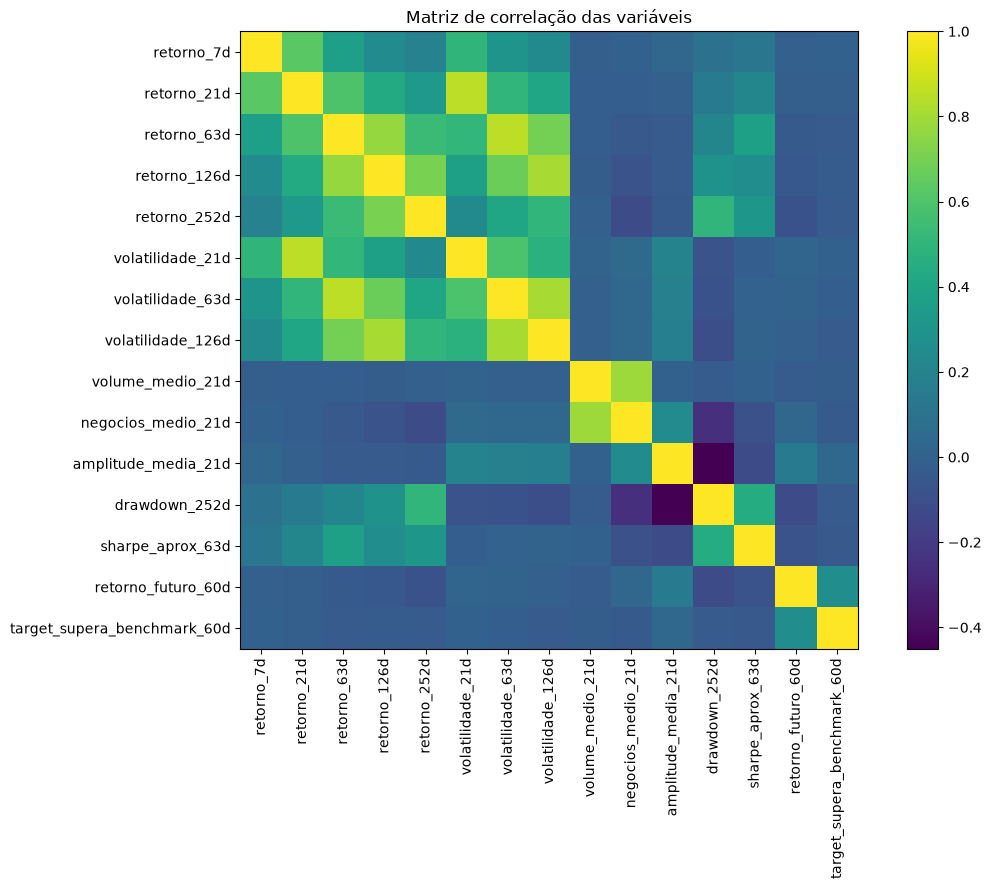

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(corr)
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.set_title("Matriz de correlação das variáveis")

fig.tight_layout()
fig.savefig(IMAGES_DIR / "matriz_correlacao.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Espera-se que retornos em janelas próximas tenham alguma correlação entre si, assim como as medidas de volatilidade.  
O target não costuma apresentar correlação linear forte com uma única variável, o que justifica o uso de modelos capazes de capturar interações entre múltiplas features.

## 14. Atenção ao vazamento de dados

Algumas colunas usam informação futura e não devem ser utilizadas como variáveis explicativas na modelagem.

Exemplos:

- `retorno_futuro_60d`;
- `retorno_futuro_60d_benchmark`;
- `target_supera_benchmark_60d`.

Essas variáveis são úteis para análise e criação do alvo, mas não devem entrar em `X` durante o treinamento dos modelos.

## 15. Classificação heurística de perfil dos ativos

Nesta etapa criamos uma camada simples de **suitability** dos ativos.

A classificação é heurística, ou seja, baseada em regras de negócio definidas a partir de:

- volatilidade média;
- drawdown médio;
- taxa de superação do benchmark.

As categorias são:

- conservador relativo;
- moderado;
- arrojado;
- especulativo.

In [26]:
def classificar_perfil_ativo(row):
    vol = row["volatilidade_media_63d"]
    drawdown = row["drawdown_medio_252d"]
    taxa = row["taxa_superacao"]

    if vol <= 0.30 and drawdown >= -0.15 and taxa >= 0.50:
        return "Conservador relativo"

    if vol <= 0.45 and drawdown >= -0.25 and taxa >= 0.48:
        return "Moderado"

    if vol <= 0.70 and drawdown >= -0.40:
        return "Arrojado"

    return "Especulativo"


risco_retorno["perfil_ativo"] = risco_retorno.apply(classificar_perfil_ativo, axis=1)

perfil_ativos = risco_retorno[
    [
        "ticker",
        "retorno_medio_60d",
        "volatilidade_media_63d",
        "taxa_superacao",
        "drawdown_medio_252d",
        "liquidez_media_21d",
        "perfil_ativo",
    ]
].sort_values(["perfil_ativo", "taxa_superacao"], ascending=[True, False])

perfil_ativos

,ticker,retorno_medio_60d,volatilidade_media_63d,taxa_superacao,drawdown_medio_252d,liquidez_media_21d,perfil_ativo
4,BPAC11,0.0731,0.4580,0.5835,-0.2170,27893062628.4123,Arrojado
21,PRIO3,0.0884,0.6010,0.5072,-0.3516,33029305589.1664,Arrojado
5,BRFS3,0.0265,0.4689,0.4952,-0.2866,19212285267.4460,Arrojado
31,VALE3,0.0254,0.3428,0.4755,-0.1986,179285282417.6270,Arrojado
22,RADL3,-0.0026,0.3674,0.4732,-0.2550,15870885752.7418,Arrojado
19,PETR3,0.0200,0.3918,0.4726,-0.1620,47277827159.3775,Arrojado
14,ITUB4,0.0129,0.2925,0.4660,-0.1791,88585180310.1972,Arrojado
28,TAEE11,0.0203,0.1918,0.4582,-0.0917,7223478623.9431,Arrojado
24,RENT3,0.0281,0.4048,0.4558,-0.1881,35568202063.7430,Arrojado
27,SUZB3,0.0141,0.3368,0.4553,-0.1982,34122089590.0585,Arrojado


In [27]:
perfil_ativos.to_csv(TABLES_DIR / "perfil_ativos_suitability.csv", index=False)

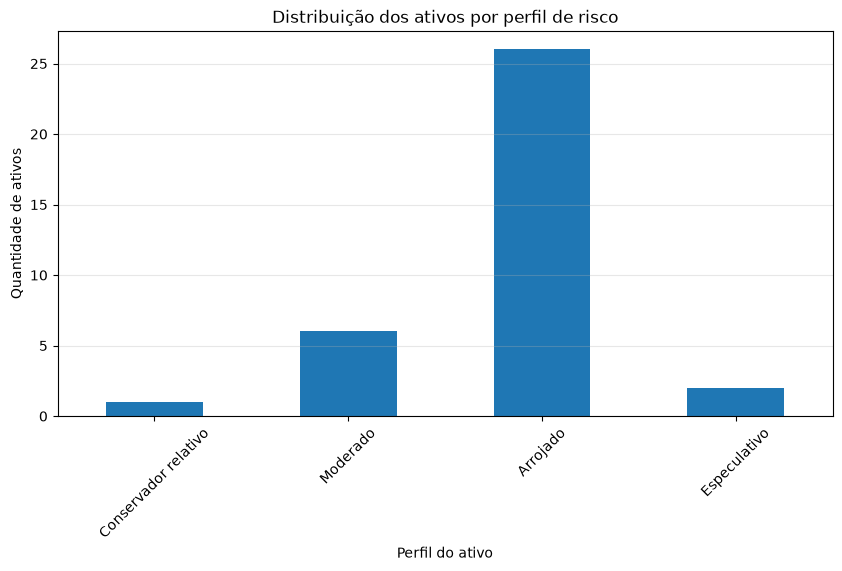

In [28]:
perfil_counts = (
    risco_retorno["perfil_ativo"]
    .value_counts()
    .reindex(["Conservador relativo", "Moderado", "Arrojado", "Especulativo"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 5))

perfil_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos ativos por perfil de risco")
ax.set_xlabel("Perfil do ativo")
ax.set_ylabel("Quantidade de ativos")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

fig.savefig(IMAGES_DIR / "distribuicao_perfil_ativos.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

### Interpretação

Essa classificação não substitui uma regra formal de suitability, mas aproxima o projeto de uma aplicação real.

Em um produto financeiro, essa camada ajudaria a evitar que ativos muito voláteis ou com drawdown severo fossem priorizados para investidores conservadores.

## 16. Salvamento das tabelas principais

Nesta etapa salvamos os principais resultados agregados para uso no relatório final e no README do GitHub.

In [29]:
ranking_superacao.to_csv(TABLES_DIR / "ranking_superacao_benchmark.csv", header=["taxa_superacao"])
retorno_medio_futuro.to_csv(TABLES_DIR / "retorno_medio_futuro_60d.csv", header=["retorno_medio_60d"])
risco_medio.to_csv(TABLES_DIR / "risco_medio_por_ativo.csv", header=["volatilidade_media_63d"])
liquidez_media.to_csv(TABLES_DIR / "liquidez_media_por_ativo.csv", header=["volume_medio_21d"])
drawdown_medio.to_csv(TABLES_DIR / "drawdown_medio_por_ativo.csv", header=["drawdown_medio_252d"])

print("Tabelas salvas em:", TABLES_DIR)

Tabelas salvas em: ..\reports\tables


## 17. Principais insights da EDA

A análise exploratória indica que:

1. A variável-alvo está relativamente balanceada, o que favorece a modelagem supervisionada.
2. Retorno médio isolado pode ser enganoso, pois alguns ativos com alto retorno também apresentam alta volatilidade e drawdown.
3. Liquidez, volatilidade e drawdown são essenciais para avaliar adequação de ativos em um contexto de fintech.
4. O mapa risco × retorno evidencia que nem todo ativo com alto retorno possui boa relação risco-retorno.
5. A análise de correlação sugere que nenhuma variável isolada explica completamente a superação do benchmark.
6. A classificação heurística de perfil dos ativos adiciona uma camada de negócio ao projeto, aproximando a solução de uma aplicação real de suitability.

## 18. Conclusão

A análise exploratória mostrou que a recomendação de ativos não deve ser baseada apenas em retorno histórico.

Para uma fintech/corretora, uma abordagem mais robusta precisa considerar simultaneamente:

- potencial de retorno;
- frequência de superação do benchmark;
- volatilidade;
- drawdown;
- liquidez;
- adequação ao perfil de risco.

Os resultados desta EDA servirão como base para a etapa de modelagem de machine learning, na qual será avaliada a capacidade de prever se um ativo tende a superar o benchmark em uma janela futura de 60 pregões.